In [31]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import numpy as np

In [32]:
train = r"D:\kaaagle_Data\test"

In [33]:
IMAGE_SIZE = 128
BATCH_SIZE = 32

In [34]:
datagen = ImageDataGenerator(rescale=1./255)

In [35]:
train_ds = datagen.flow_from_directory(
    r"D:\kaaagle_Data\train",
    target_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical'
)
test_ds = datagen.flow_from_directory(
    r"D:\kaaagle_Data\test",
    target_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical'
)
val_ds = datagen.flow_from_directory(
    r'D:\kaaagle_Data\val',
    target_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical'
)

Found 20450 images belonging to 3 classes.
Found 2569 images belonging to 3 classes.
Found 2534 images belonging to 3 classes.


In [36]:
class_names = list(train_ds.class_indices.keys())

In [37]:
images,labels = next(train_ds)

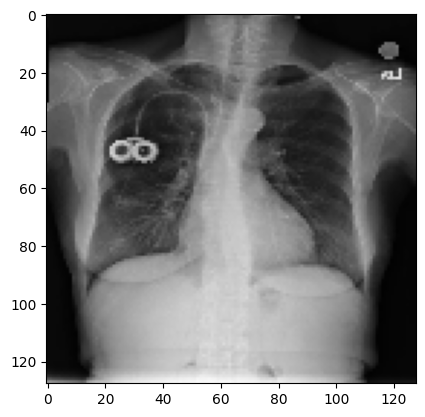

In [38]:
plt.imshow(images[30])

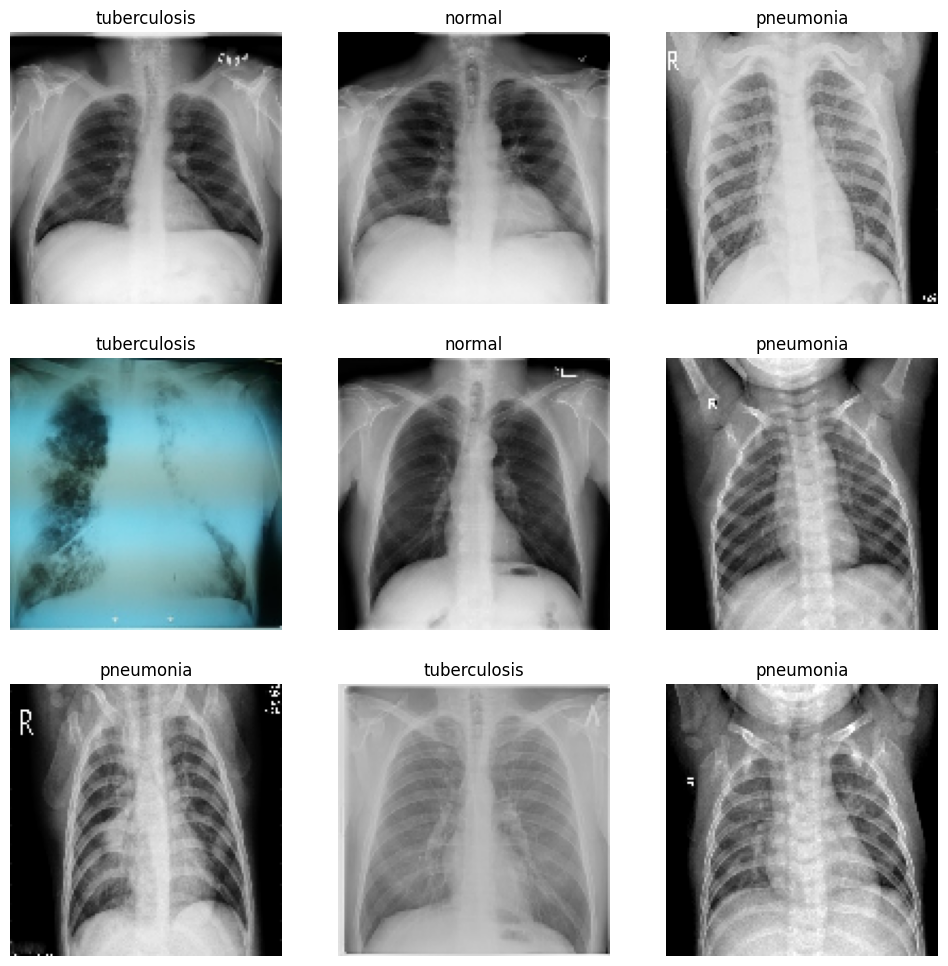

In [39]:
plt.figure(figsize=(12,12))
for i in range(9):
    plt.subplot(3 ,3 , i + 1)
    plt.imshow(images[i])
    label = labels[i]
    if label.ndim > 0:  # one-hot encoded
        class_idx = np.argmax(label)
    else:
        class_idx = int(label)
    class_name = list(class_names)[class_idx]
    plt.title(class_name)
    plt.axis('off')

In [43]:
from tensorflow.keras.applications import VGG16

input_shape = (IMAGE_SIZE,IMAGE_SIZE,3)
n_class = len(class_names)

base_model = VGG16(weights='imagenet',include_top=False,input_shape=input_shape)
base_model.trainable = False

X_ray = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128,activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(n_class,activation='softmax')
    
])

X_ray.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)


In [44]:
X_ray.fit(train_ds,validation_data=val_ds,epochs=3)

C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
640/640 ━━━━━━━━━━━━━━━━━━━━ 1315s 2s/step - accuracy: 0.7227 - loss: 0.5480 - val_accuracy: 0.7510 - val_loss: 0.4412
Epoch 2/3
640/640 ━━━━━━━━━━━━━━━━━━━━ 1235s 2s/step - accuracy: 0.7467 - loss: 0.4697 - val_accuracy: 0.7612 - val_loss: 0.4268
Epoch 3/3
640/640 ━━━━━━━━━━━━━━━━━━━━ 1197s 2s/step - accuracy: 0.7550 - loss: 0.4495 - val_accuracy: 0.7573 - val_loss: 0.4176


In [45]:
X_ray.predict(test_ds)

C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


81/81 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step


array([[6.2711310e-01, 1.1169432e-09, 3.7288690e-01],
       [6.1545759e-01, 1.0451721e-09, 3.8454235e-01],
       [5.1283124e-03, 2.6035343e-07, 9.9487150e-01],
       ...,
       [6.2714982e-01, 1.4564175e-09, 3.7285021e-01],
       [9.1572078e-03, 2.5287585e-07, 9.9084258e-01],
       [3.6162007e-01, 5.7147825e-10, 6.3837987e-01]],
      shape=(2569, 3), dtype=float32)

In [46]:
X_ray.evaluate(test_ds)

81/81 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.7524 - loss: 0.4270


[0.4269755482673645, 0.7524328827857971]

In [ ]:
def predict_and_show(model, dataset, class_names, num_images=9):
    plt.figure(figsize=(13, 13))
    
    
    predictions = model.predict(images)
    
    for i in range(num_images):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        pred_idx = np.argmax(predictions[i])
        true_idx = np.argmax(labels[i])
        
        title = f"Pred: {class_names[pred_idx]}\nTrue: {class_names[true_idx]}"
        plt.title(title, color=("green" if pred_idx == true_idx else "red"))
        plt.axis("off")

    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


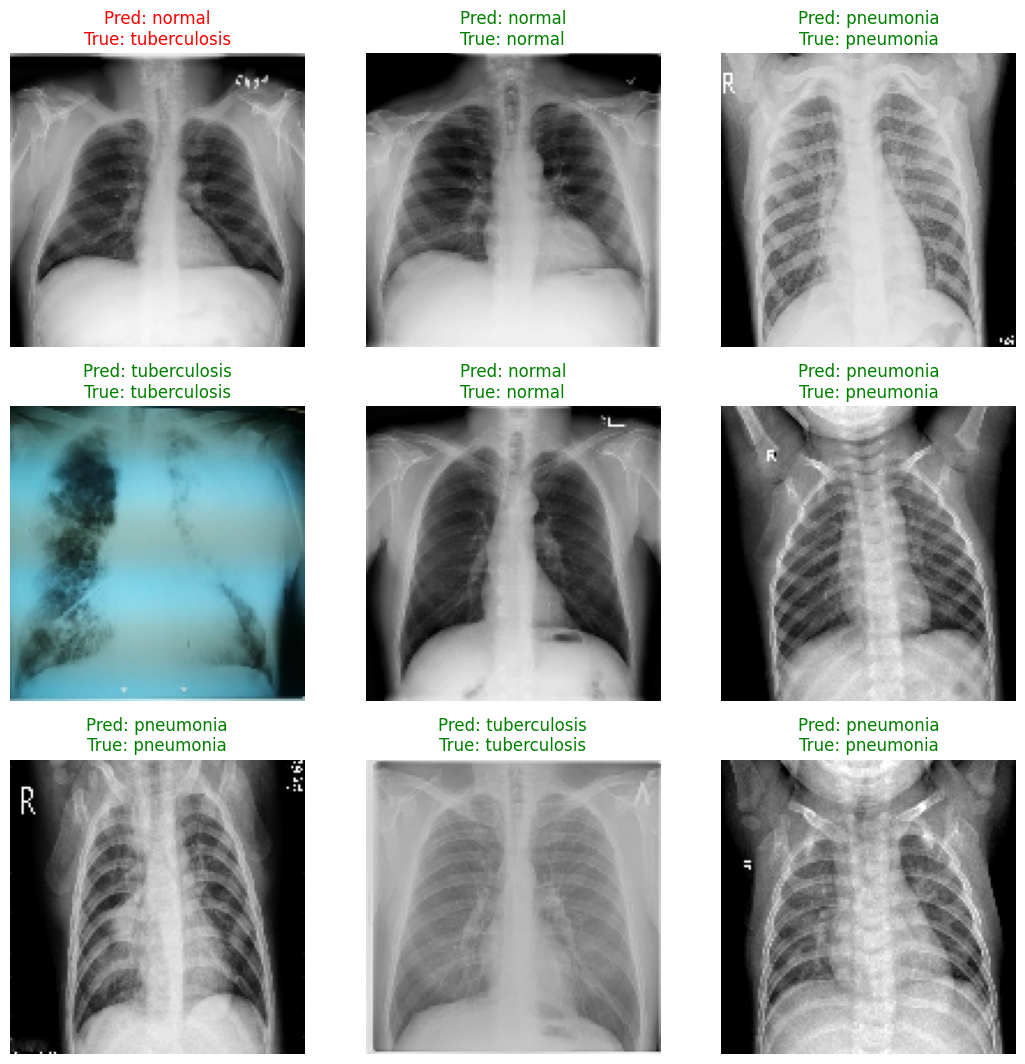

In [59]:
predict_and_show(X_ray,test_ds,class_names,9)